In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [9]:
df = pd.read_csv("Pokemon.csv")

In [10]:
df.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


In [11]:
df.shape

(800, 13)

In [12]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [38]:
df.isnull().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [44]:
df['Type 2'] = df['Type 2'].fillna('None')

In [46]:
df['Type 2'].isnull().count()

np.int64(800)

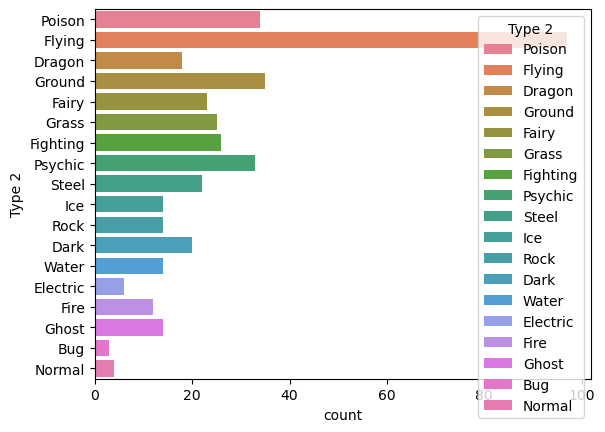

In [43]:
sns.countplot(df, y = "Type 2", hue = 'Type 2')
plt.show()

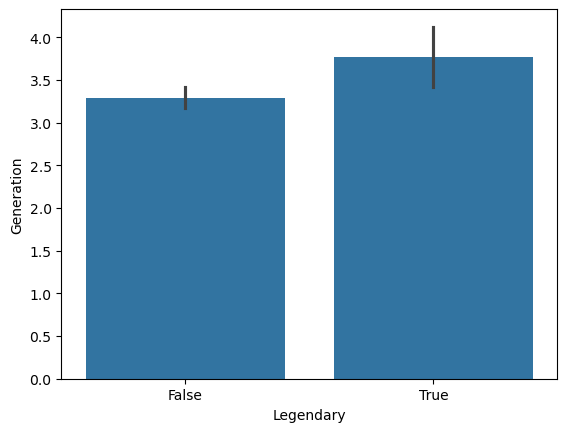

In [15]:
sns.barplot(data= df, x= "Legendary", y ="Generation") 
plt.show()

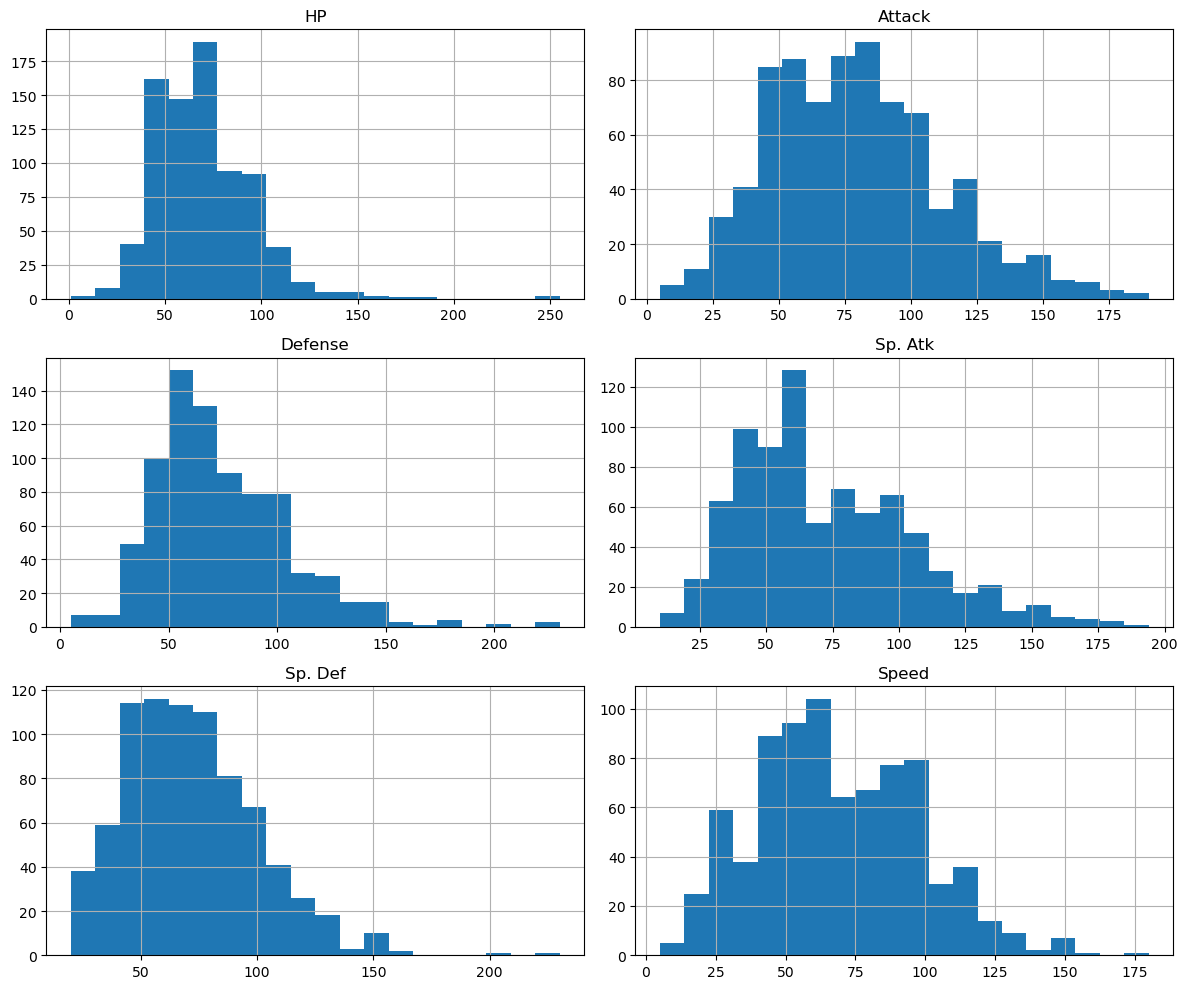

In [36]:
stats = ['HP', 'Attack', 'Defense',
         'Sp. Atk', 'Sp. Def', 'Speed']

df[stats].hist(
    figsize=(12,10),
    bins=20
)

plt.tight_layout()
plt.show()

In [52]:
stats = ['HP',
            'Attack',
            'Defense',
            'Sp. Atk',
            'Sp. Def',
            'Speed']

X = df[stats]

In [53]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [54]:
print(X_scaled[:5])

[[-0.95062622 -0.92490618 -0.79715364 -0.2391303  -0.24818854 -0.80150318]
 [-0.3628221  -0.5241302  -0.34791742  0.21955954  0.29115635 -0.28501525]
 [ 0.42091674  0.09244823  0.29384863  0.83114599  1.01028289  0.40363531]
 [ 0.42091674  0.64736882  1.57738071  1.50389108  1.72940942  0.40363531]
 [-1.18574787 -0.83241942 -0.98968346 -0.39202691 -0.78753344 -0.11285261]]


In [56]:
df_encoded = pd.get_dummies(
    df[['Type 1','Generation']],
    drop_first=True
)

In [57]:
X_final = pd.concat(
    [df[features], df_encoded],
    axis=1
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_final)

In [58]:
wcss = []

for k in range(1,16):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

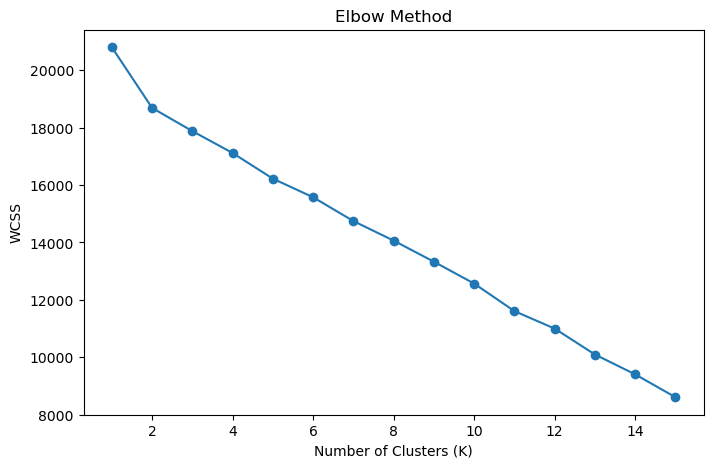

In [62]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,16),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [63]:
sil_scores = []

for k in range(2,16):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    sil_scores.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.0993
K=3, Silhouette Score=0.1110
K=4, Silhouette Score=0.1217
K=5, Silhouette Score=0.1486
K=6, Silhouette Score=0.1565
K=7, Silhouette Score=0.1270
K=8, Silhouette Score=0.1457
K=9, Silhouette Score=0.1911
K=10, Silhouette Score=0.2034
K=11, Silhouette Score=0.2149
K=12, Silhouette Score=0.2493
K=13, Silhouette Score=0.2605
K=14, Silhouette Score=0.3069
K=15, Silhouette Score=0.3321


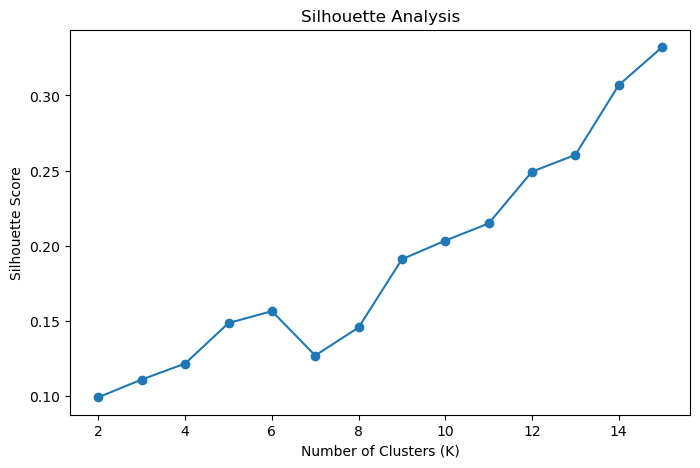

In [64]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,16),
    sil_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()


In [65]:
import numpy as np
best_k = np.argmax(sil_scores) + 2

print("Best K =", best_k)

Best K = 15


In [66]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df[['Name','Cluster']].head())

                    Name  Cluster
0              Bulbasaur        1
1                Ivysaur        1
2               Venusaur        1
3  VenusaurMega Venusaur        1
4             Charmander        4


In [67]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [68]:
df['Cluster'] = clusters

df[['Name','Cluster']].head()

,Name,Cluster
0,Bulbasaur,1
1,Ivysaur,1
2,Venusaur,1
3,VenusaurMega Venusaur,1
4,Charmander,4


In [73]:
for cluster in sorted(df['Cluster'].unique()):

    print(f"\nCluster {cluster}")

    sample = df[df['Cluster']==cluster][
        ['Name','Type 1','HP','Attack','Speed']
    ].head(10)

    print(sample)


Cluster 0
                       Name Type 1  HP  Attack  Speed
9                  Squirtle  Water  44      48     43
10                Wartortle  Water  59      63     58
11                Blastoise  Water  79      83     78
12  BlastoiseMega Blastoise  Water  79     103     78
13                 Caterpie    Bug  45      30     45
14                  Metapod    Bug  50      20     30
15               Butterfree    Bug  60      45     70
16                   Weedle    Bug  40      35     50
17                   Kakuna    Bug  45      25     35
18                 Beedrill    Bug  65      90     75

Cluster 1
                     Name Type 1  HP  Attack  Speed
0               Bulbasaur  Grass  45      49     45
1                 Ivysaur  Grass  60      62     60
2                Venusaur  Grass  80      82     80
3   VenusaurMega Venusaur  Grass  80     100     80
48                 Oddish  Grass  45      50     30
49                  Gloom  Grass  60      65     40
50              Vile

In [74]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

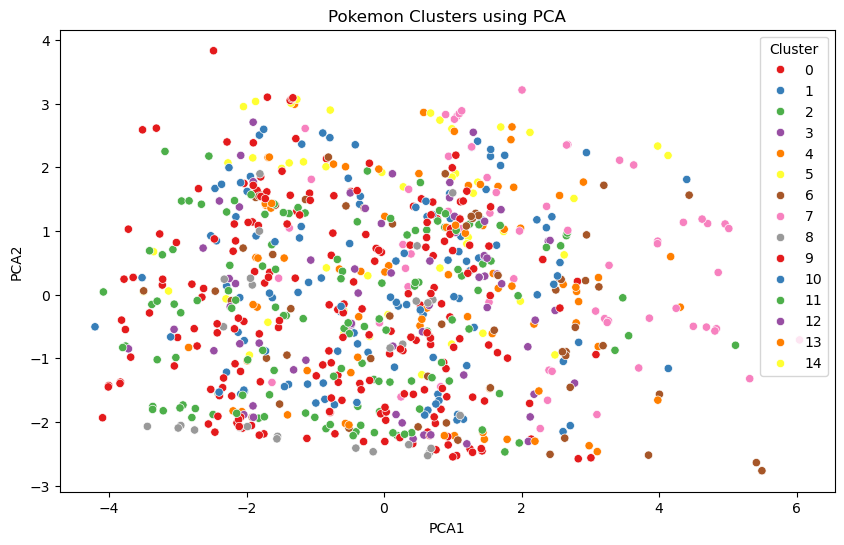

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1'
)

plt.title('Pokemon Clusters using PCA')
plt.show()

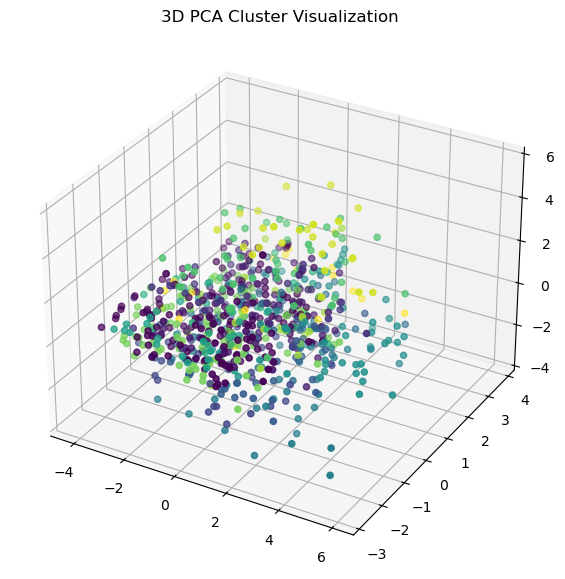

In [77]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)

X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=df['Cluster']
)

ax.set_title('3D PCA Cluster Visualization')

plt.show()

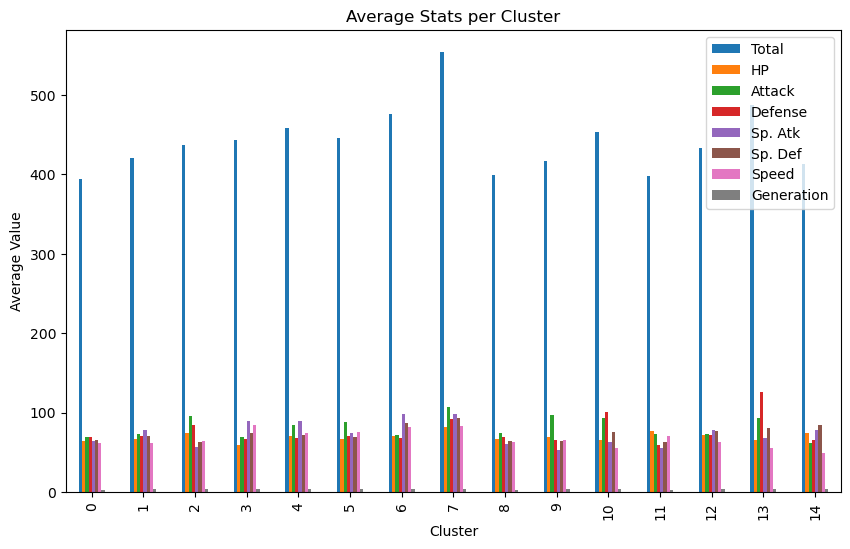

In [78]:
cluster_means = df.groupby('Cluster')[features].mean()

cluster_means.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Stats per Cluster")
plt.ylabel("Average Value")
plt.show()

In [79]:
cluster_summary = df.groupby('Cluster')[features].mean()

print(cluster_summary)

              Total         HP      Attack     Defense    Sp. Atk    Sp. Def      Speed  Generation
Cluster                                                                                            
0        394.556150  64.176471   68.855615   69.689840  64.411765  65.299465  62.122995    3.101604
1        421.142857  67.271429   73.214286   70.800000  77.500000  70.428571  61.928571    3.357143
2        437.500000  73.781250   95.750000   84.843750  56.468750  62.750000  63.906250    3.156250
3        443.409091  59.795455   69.090909   66.295455  90.022727  73.704545  84.500000    3.272727
4        458.076923  69.903846   84.769231   67.769231  88.980769  72.211538  74.442308    3.211538
5        445.741935  66.806452   88.387097   70.225806  74.645161  69.516129  76.161290    4.032258
6        475.947368  70.631579   71.456140   67.684211  98.403509  86.280702  81.491228    3.385965
7        554.253968  81.365079  106.507937   91.507937  98.190476  92.984127  83.698413    3.904762


In [82]:
legendary_counts = df.groupby('Cluster')['Legendary'].sum()

print(legendary_counts)

Cluster
0      1
1      3
2      4
3      4
4      5
5      2
6     14
7     20
8      0
9      0
10     4
11     1
12     2
13     4
14     1
Name: Legendary, dtype: int64


In [83]:
print(
    "Cluster with most Legendary Pokemon:",
    legendary_counts.idxmax()
)

Cluster with most Legendary Pokemon: 7


In [84]:
pd.crosstab(
    df['Cluster'],
    df['Type 1']
)

Type 1,Bug,Dark,Dragon,Electric,Fairy,Fighting,Fire,Flying,Ghost,Grass,Ground,Ice,Normal,Poison,Psychic,Rock,Steel,Water
Cluster,,,,,,,,,,,,,,,,,,
0,64,0,0,0,0,0,0,1,13,0,0,0,0,0,0,0,0,109
1,0,0,0,0,0,0,0,0,0,70,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,32,0,0,0,0,0,0,0
3,0,0,0,44,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,52,0,0,0,0,0,0,0,0,0,0,0
5,0,31,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,57,0,0,0
7,5,0,32,0,0,0,0,3,19,0,0,0,1,0,0,0,0,3
8,0,0,0,0,0,0,0,0,0,0,0,0,0,28,0,0,0,0


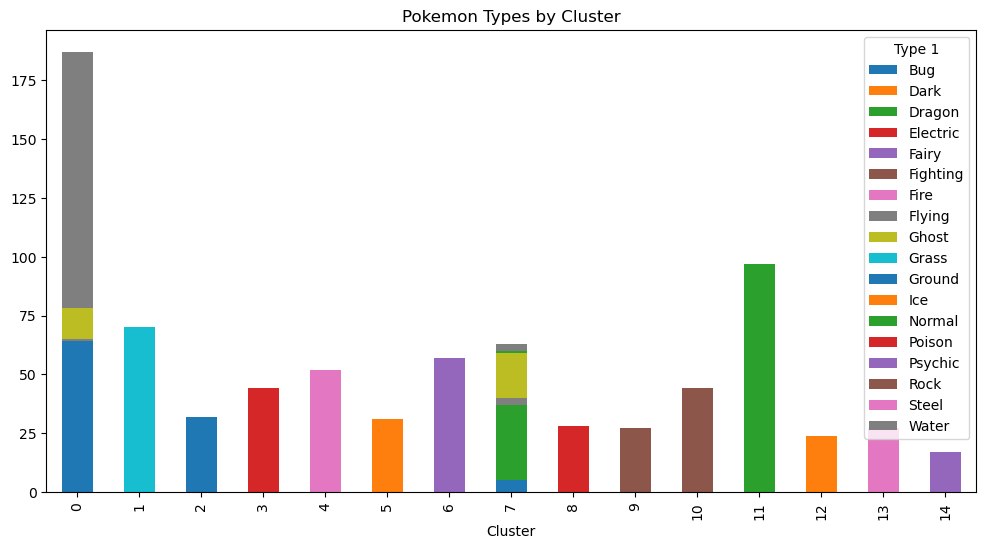

In [85]:
type_cluster = pd.crosstab(
    df['Cluster'],
    df['Type 1']
)

type_cluster.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Pokemon Types by Cluster")
plt.show()

In [86]:
pd.crosstab(
    df['Cluster'],
    df['Generation']
)

Generation,1,2,3,4,5,6
Cluster,,,,,,
0,46,28,39,23,37,14
1,13,9,13,15,15,5
2,8,3,7,4,10,0
3,9,7,5,12,8,3
4,14,8,8,5,9,8
5,0,6,6,3,13,3
6,11,7,12,8,14,5
7,6,3,17,12,15,10
8,14,1,3,6,2,2


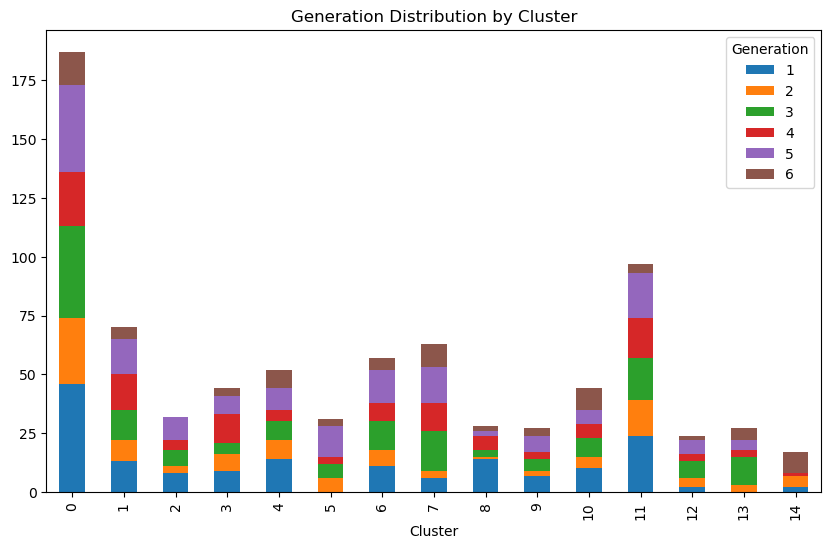

In [87]:
gen_cluster = pd.crosstab(
    df['Cluster'],
    df['Generation']
)

gen_cluster.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Generation Distribution by Cluster")
plt.show()